# 04 - Pattern Mining (ST-DBSCAN + Apriori)

## 1. Setup
ST-DBSCAN and Apriori are the "pattern discovery" pieces from the proposal:
- **ST-DBSCAN**: finds spatio-temporal clusters ("plumes") of elevated pollution across cities.
- **Apriori**: mines association rules like "Dhaka elevated at t -> Chittagong elevated at t+2" for cross-city propagation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from mlxtend.frequent_patterns import apriori, association_rules
%matplotlib inline

ELEVATED_THRESHOLD = 100
EPS_SPATIAL_KM = 200
EPS_TEMPORAL_HR = 2
MIN_SAMPLES = 3

CITY_COORDS = {
    "Dhaka":      (23.8103, 90.4125),
    "Chittagong": (22.3569, 91.7832),
    "Sylhet":     (24.8949, 91.8687),
    "Rajshahi":   (24.3745, 88.6042),
    "Khulna":     (22.8456, 89.5403),
    "Barisal":    (22.7010, 90.3535),
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_distance_matrix(coords):
    cities = list(coords.keys())
    dist = pd.DataFrame(index=cities, columns=cities, dtype=float)
    for a in cities:
        for b in cities:
            dist.loc[a, b] = 0.0 if a == b else haversine(*coords[a], *coords[b])
    return dist

dist_matrix = build_distance_matrix(CITY_COORDS)
dist_matrix.round(1)

,Dhaka,Chittagong,Sylhet,Rajshahi,Khulna,Barisal
Dhaka,0.0,214.0,190.5,194.0,139.4,123.5
Chittagong,214.0,0.0,282.3,394.5,236.6,151.7
Sylhet,190.5,282.3,0.0,335.0,328.6,288.6
Rajshahi,194.0,394.5,335.0,0.0,194.9,257.7
Khulna,139.4,236.6,328.6,194.9,0.0,84.9
Barisal,123.5,151.7,288.6,257.7,84.9,0.0


## 2. Load feature-engineered data

In [3]:
train = pd.read_csv("train_features.csv")
test = pd.read_csv("test_features.csv")
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])
train.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,pm25_roll_std_6,pm25_roll_mean_24,pm25_roll_std_24,idw_pm25_neighbors,idw_wind_u_neighbors,idw_wind_v_neighbors,regional_elevated_frac,spike_t+1,spike_t+2,spike_t+3
0,173665,2022,8,5,0,8.5,13.5,1.0,3.1,118.0,...,0.444597,6.275000,1.139889,12.469896,-1.727341,-0.125239,0.0,0,0,0
1,173666,2022,8,5,1,7.1,11.5,1.1,2.9,119.0,...,0.630608,6.320833,1.207217,10.508043,-1.644307,0.118206,0.0,0,0,0
2,173667,2022,8,5,2,6.4,10.3,1.1,2.7,120.0,...,0.624233,6.408333,1.183185,8.198478,-1.921739,0.954034,0.0,0,0,0
3,173668,2022,8,5,3,6.3,9.9,1.1,2.3,119.0,...,0.714609,6.479167,1.125970,7.725460,-2.055481,1.598997,0.0,0,0,0
4,173669,2022,8,5,4,5.8,9.1,1.0,2.1,117.0,...,0.793515,6.537500,1.075745,8.758535,-2.352543,1.386802,0.0,0,0,0


## 3. ST-DBSCAN implementation
Two points are spatio-temporal neighbors if they're within `EPS_SPATIAL_KM`
of each other AND within `EPS_TEMPORAL_HR` hours. Standard density-based
cluster expansion runs on top of that joint neighborhood definition.

We restrict candidates to a small time window using binary search
(`np.searchsorted`) instead of scanning all points - a naive O(n^2) scan
is too slow/memory-heavy once you have 10,000+ elevated points.

In [4]:
def st_dbscan(points, dist_matrix, eps_spatial, eps_temporal_hr, min_samples):
    points = points.sort_values("datetime").reset_index(drop=True)
    n = len(points)
    labels = np.full(n, -2, dtype=int)  # -2 unvisited, -1 noise, >=0 cluster id
    stations = points["station"].values
    times = points["datetime"].values.astype("datetime64[h]").astype(np.int64)

    def region_query(idx):
        s_p, t_p = stations[idx], times[idx]
        lo = np.searchsorted(times, t_p - eps_temporal_hr, side="left")
        hi = np.searchsorted(times, t_p + eps_temporal_hr, side="right")
        neighbor_idx = []
        for j in range(lo, hi):
            if j == idx:
                continue
            d = dist_matrix.loc[s_p, stations[j]]
            if d <= eps_spatial:
                neighbor_idx.append(j)
        return neighbor_idx

    cluster_id = 0
    for i in range(n):
        if labels[i] != -2:
            continue
        neighbors = region_query(i)
        if len(neighbors) + 1 < min_samples:
            labels[i] = -1
            continue
        labels[i] = cluster_id
        queue = deque(neighbors)
        while queue:
            j = queue.popleft()
            if labels[j] == -1:
                labels[j] = cluster_id
            if labels[j] != -2:
                continue
            labels[j] = cluster_id
            j_neighbors = region_query(j)
            if len(j_neighbors) + 1 >= min_samples:
                queue.extend(j_neighbors)
        cluster_id += 1
    return labels

def run_st_dbscan(df, dist_matrix):
    elevated = df[df["PM2.5"] > ELEVATED_THRESHOLD][["station", "datetime", "PM2.5"]].copy()
    elevated["datetime"] = pd.to_datetime(elevated["datetime"])
    elevated = elevated.reset_index(drop=True)

    print(f"Running ST-DBSCAN on {len(elevated)} elevated points "
          f"(eps_spatial={EPS_SPATIAL_KM}km, eps_temporal={EPS_TEMPORAL_HR}h, min_samples={MIN_SAMPLES})...")

    labels = st_dbscan(elevated, dist_matrix, EPS_SPATIAL_KM, EPS_TEMPORAL_HR, MIN_SAMPLES)
    elevated["plume_cluster"] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"  -> found {n_clusters} plume clusters, {n_noise} noise points")

    plume_sizes = elevated[elevated["plume_cluster"] != -1].groupby("plume_cluster").size().rename("plume_size")
    elevated = elevated.merge(plume_sizes, left_on="plume_cluster", right_index=True, how="left")
    elevated["plume_size"] = elevated["plume_size"].fillna(0)
    elevated["in_plume"] = (elevated["plume_cluster"] != -1).astype(int)
    return elevated[["station", "datetime", "in_plume", "plume_size", "plume_cluster"]]

plume_train = run_st_dbscan(train, dist_matrix)
plume_test = run_st_dbscan(test, dist_matrix)

Running ST-DBSCAN on 10080 elevated points (eps_spatial=200km, eps_temporal=2h, min_samples=3)...
  -> found 397 plume clusters, 127 noise points
Running ST-DBSCAN on 2281 elevated points (eps_spatial=200km, eps_temporal=2h, min_samples=3)...
  -> found 104 plume clusters, 40 noise points


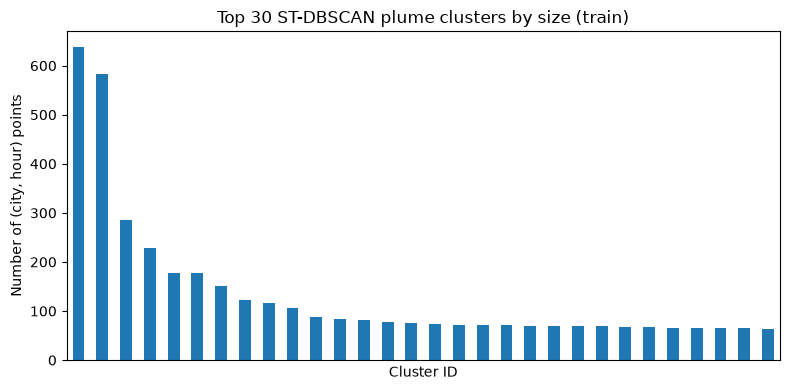

In [5]:
# visualize plume cluster sizes
plume_counts = plume_train[plume_train["plume_cluster"] != -1]["plume_cluster"].value_counts()
plt.figure(figsize=(8, 4))
plume_counts.sort_values(ascending=False).head(30).plot(kind="bar")
plt.title("Top 30 ST-DBSCAN plume clusters by size (train)")
plt.xlabel("Cluster ID")
plt.ylabel("Number of (city, hour) points")
plt.xticks([])
plt.tight_layout()
plt.show()

In [6]:
train = train.merge(plume_train, on=["station", "datetime"], how="left")
test = test.merge(plume_test, on=["station", "datetime"], how="left")
for d in (train, test):
    d["in_plume"] = d["in_plume"].fillna(0).astype(int)
    d["plume_size"] = d["plume_size"].fillna(0)
    d.drop(columns=["plume_cluster"], inplace=True)

print(f"% rows in a plume (train): {train['in_plume'].mean()*100:.2f}%")

% rows in a plume (train): 5.55%


## 4. Apriori association rules
Builds a transaction table: for each hour, which cities are elevated *now*
vs. 1/2/3 hours ago. Mines rules like `Barisal_lag1 -> Khulna_now`.

`max_len=2` keeps itemsets pairwise - the `*_now`/`*_lag1/2/3` columns per
city are highly correlated with each other, so unrestricted Apriori explodes
combinatorially. Pairwise rules are also exactly what "A predicts B" needs.

In [7]:
def build_transaction_table(df, lags=(1, 2, 3)):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["elevated"] = df["PM2.5"] > ELEVATED_THRESHOLD
    pivot = df.pivot(index="datetime", columns="station", values="elevated").fillna(False)
    pivot = pivot.sort_index()

    table = pd.DataFrame(index=pivot.index)
    for city in pivot.columns:
        table[f"{city}_now"] = pivot[city]
        for lag in lags:
            table[f"{city}_lag{lag}"] = pivot[city].shift(lag).fillna(False).astype(bool)
    return table.astype(bool)

def mine_association_rules(transaction_table, min_support=0.01, min_confidence=0.3):
    frequent_itemsets = apriori(transaction_table, min_support=min_support,
                                 use_colnames=True, max_len=2)
    if frequent_itemsets.empty:
        return pd.DataFrame(), frequent_itemsets

    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

    def is_propagation_rule(row):
        ante = list(row["antecedents"])
        cons = list(row["consequents"])
        if len(ante) != 1 or len(cons) != 1:
            return False
        a, c = ante[0], cons[0]
        a_city = a.split("_lag")[0] if "_lag" in a else a.split("_now")[0]
        c_city = c.split("_lag")[0] if "_lag" in c else c.split("_now")[0]
        return "_lag" in a and "_now" in c and a_city != c_city

    rules["is_propagation"] = rules.apply(is_propagation_rule, axis=1)
    propagation_rules = rules[rules["is_propagation"]].sort_values("confidence", ascending=False)
    return propagation_rules, frequent_itemsets

transactions = build_transaction_table(train, lags=(1, 2, 3))
propagation_rules, frequent_itemsets = mine_association_rules(transactions, min_support=0.01, min_confidence=0.3)

display_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
propagation_rules[display_cols].head(15)

,antecedents,consequents,support,confidence,lift
42,frozenset({Barisal_lag1}),frozenset({Khulna_now}),0.040897,0.796610,11.004490
33,frozenset({Barisal_lag1}),frozenset({Dhaka_now}),0.037617,0.732725,9.704707
68,frozenset({Barisal_lag2}),frozenset({Khulna_now}),0.037584,0.732073,10.112964
49,frozenset({Barisal_lag1}),frozenset({Rajshahi_now}),0.036580,0.712516,6.364720
220,frozenset({Khulna_lag1}),frozenset({Rajshahi_now}),0.050669,0.699954,6.252502
59,frozenset({Barisal_lag2}),frozenset({Dhaka_now}),0.034639,0.674707,8.936274
91,frozenset({Barisal_lag3}),frozenset({Khulna_now}),0.034371,0.669492,9.248454
75,frozenset({Barisal_lag2}),frozenset({Rajshahi_now}),0.034237,0.666884,5.957098
234,frozenset({Khulna_lag2}),frozenset({Rajshahi_now}),0.047590,0.657420,5.872561
263,frozenset({Sylhet_lag1}),frozenset({Rajshahi_now}),0.012617,0.643345,5.746828


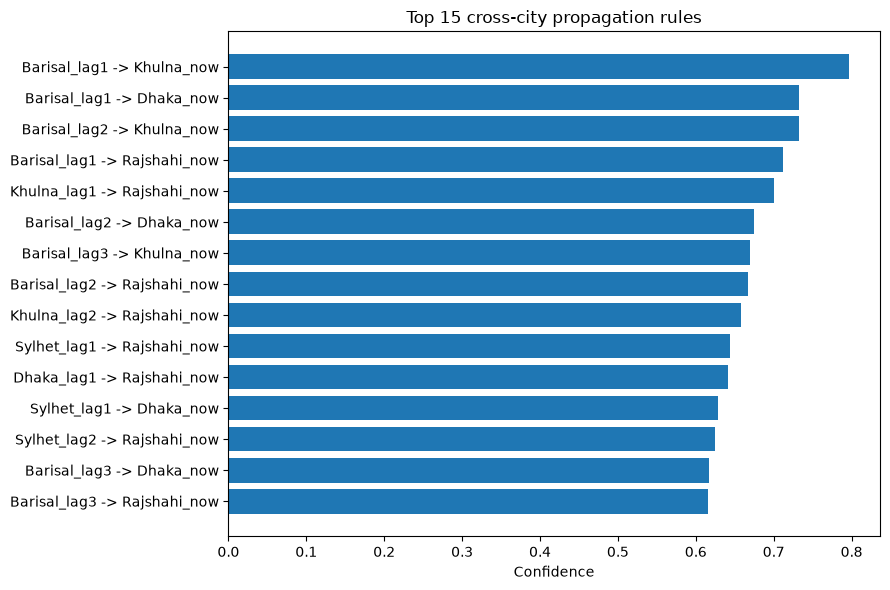

In [8]:
# visualize top rules by confidence
top_rules = propagation_rules.head(15).copy()
top_rules["rule_label"] = top_rules.apply(
    lambda r: f"{list(r['antecedents'])[0]} -> {list(r['consequents'])[0]}", axis=1)

plt.figure(figsize=(9, 6))
plt.barh(top_rules["rule_label"][::-1], top_rules["confidence"][::-1])
plt.xlabel("Confidence")
plt.title("Top 15 cross-city propagation rules")
plt.tight_layout()
plt.show()

## 5. Turn rules into a per-row feature

In [9]:
def add_apriori_signal_feature(df, propagation_rules):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["elevated"] = df["PM2.5"] > ELEVATED_THRESHOLD
    pivot = df.pivot(index="datetime", columns="station", values="elevated").fillna(False)

    signal = pd.DataFrame(0.0, index=pivot.index, columns=pivot.columns)
    if not propagation_rules.empty:
        for _, rule in propagation_rules.iterrows():
            ante = list(rule["antecedents"])[0]
            cons = list(rule["consequents"])[0]
            ante_city, lag_str = ante.split("_lag")
            cons_city = cons.split("_now")[0]
            lag = int(lag_str)
            ante_true = pivot[ante_city].shift(lag).fillna(False)
            conf = rule["confidence"]
            signal[cons_city] = np.where(ante_true & (conf > signal[cons_city]), conf, signal[cons_city])

    signal = signal.stack().rename("apriori_propagation_signal").reset_index()
    signal.columns = ["datetime", "station", "apriori_propagation_signal"]
    return signal

signal_train = add_apriori_signal_feature(train, propagation_rules)
signal_test = add_apriori_signal_feature(test, propagation_rules)

train = train.merge(signal_train, on=["station", "datetime"], how="left")
test = test.merge(signal_test, on=["station", "datetime"], how="left")

print(f"apriori_propagation_signal > 0 (train): {(train['apriori_propagation_signal']>0).mean()*100:.2f}%")

apriori_propagation_signal > 0 (train): 10.96%


## 6. Save

In [10]:
train.to_csv("train_features_v2.csv", index=False)
test.to_csv("test_features_v2.csv", index=False)
print("Saved train_features_v2.csv", train.shape, "and test_features_v2.csv", test.shape)
print("New columns: in_plume, plume_size, apriori_propagation_signal")

Saved train_features_v2.csv (179280, 47) and test_features_v2.csv (28800, 47)
New columns: in_plume, plume_size, apriori_propagation_signal
